# AR(1) vs HMM-AR(1) Prediction Performance

This notebook investigates when an HMM-AR(1) model outperforms a single AR(1) model in one-step-ahead predictions, based on simulated data. We vary the "stickiness" of states (probability of staying in the current state), the difference in AR coefficients (β), and sample size (T). Performance is evaluated using out-of-sample RMSE on predictions.

## Key Concepts
- **Stickiness**: Controlled by the diagonal of the transition matrix P (p_stay = p11 = p22).
- **Parameter Difference**: β2 - β1.
- **Evaluation**: Compare RMSE for single AR(1) vs. HMM on holdout data.
- **Predictions**:
  - Single AR(1): y_{t+1} = ρ * y_t
  - HMM: E[y_{t+1} | data] = sum_k α_t[k] * β_k * y_t

## Imports and Setup

In [3]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from methods.hmm_ar_1_k_states import (
    simulate_rs_ar1,
    fit_model
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import plotly.express as px

from methods.hmm_utils import (
    fit_single_ar1, predict_single_ar1,
    fit_hmm_robust, predict_hmm_mixture,
    compute_rmse, evaluate_predictions
)


## Experiment: Vary Stickiness, Difference, and Sample Size

We simulate data with varying p_stay (stickiness), β difference, and T. For each combination, fit models on 80% training data and evaluate RMSE on 20% test data.

One Beta is fixed.

In [4]:


# Parameters
p_stay_vals = np.array([0.6, 0.8, 0.9, 0.95, 0.98])
diff_vals = np.array([0.1, 0.3, 0.5, 0.7])
T_vals = [300, 500, 1000, 2000]
n_rep = 5
sigma = np.array([0.5, 1.0])

results = []

for p_stay in p_stay_vals:
    P = np.array([[p_stay, 1-p_stay], [1-p_stay, p_stay]])
    print(f"Processing p_stay={p_stay:.2f}")

    for diff in diff_vals:
        beta = np.array([0.2, 0.2 + diff])

        for T in T_vals:
            for rep in range(n_rep):
                y, _ = simulate_rs_ar1(T=T, beta=beta, sigma=sigma, P=P, seed=rep*100 + int(p_stay*100))

                split = int(0.8 * T)
                y_train, y_test = y[:split], y[split:]

                # Single AR(1)
                rho_hat, sigma_hat = fit_single_ar1(y_train)
                pred_mean_ar1, _, _ = predict_single_ar1(y_train, y_test, rho_hat, sigma_hat)
                rmse_single = compute_rmse(y_test, pred_mean_ar1)

                # HMM
                try:
                    _, params_hat = fit_hmm_robust(y_train, K=2, n_starts=10, seed=rep)
                    pred_mean_hmm, _, _ = predict_hmm_mixture(y_train, y_test, params_hat)
                    rmse_hmm = compute_rmse(y_test, pred_mean_hmm)
                except Exception as e:
                    print(f"HMM fit error: {e}")
                    rmse_hmm = np.nan

                results.append({
                    'p_stay': p_stay,
                    'diff': diff,
                    'T': T,
                    'rep': rep,
                    'rmse_single': rmse_single,
                    'rmse_hmm': rmse_hmm,
                    'rmse_diff': rmse_single - rmse_hmm
                })

df = pd.DataFrame(results)
df_agg = df.groupby(['p_stay', 'diff', 'T']).agg({'rmse_diff': 'mean'}).reset_index()


Processing p_stay=0.60
Processing p_stay=0.80


/Users/adnerolstad/Github/STK-MAT2011/code/methods/hmm_ar_1_k_states.py:89: RuntimeWarning: overflow encountered in exp
  sigma = np.exp(sigma_raw)


Processing p_stay=0.90
Processing p_stay=0.95
Processing p_stay=0.98


## Visualizations

Heatmaps show the average RMSE difference (HMM - Single AR(1)). Positive values indicate HMM performs better.

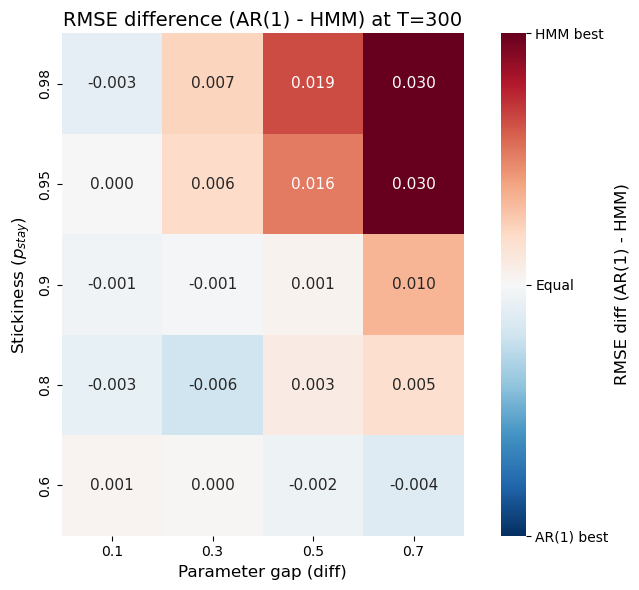

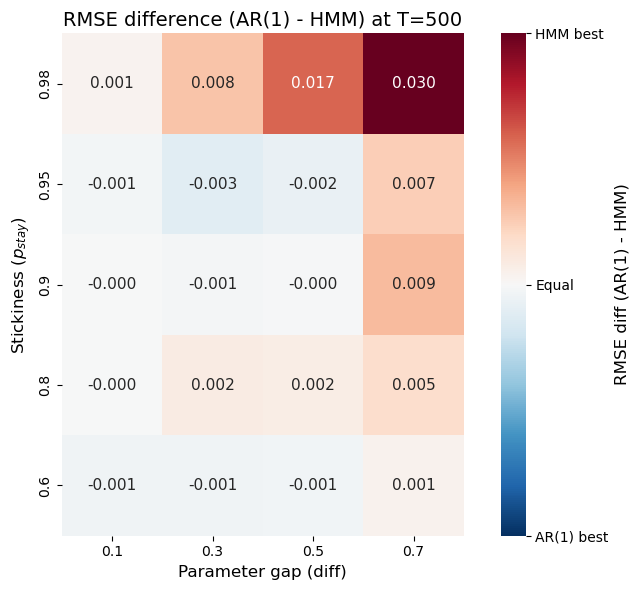

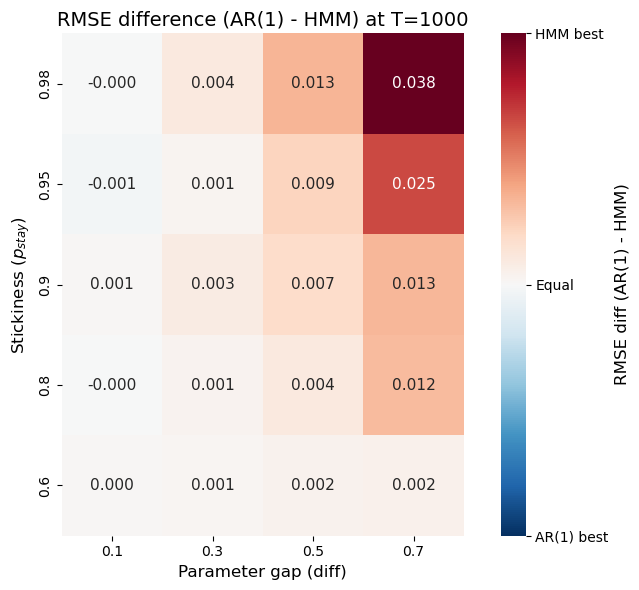

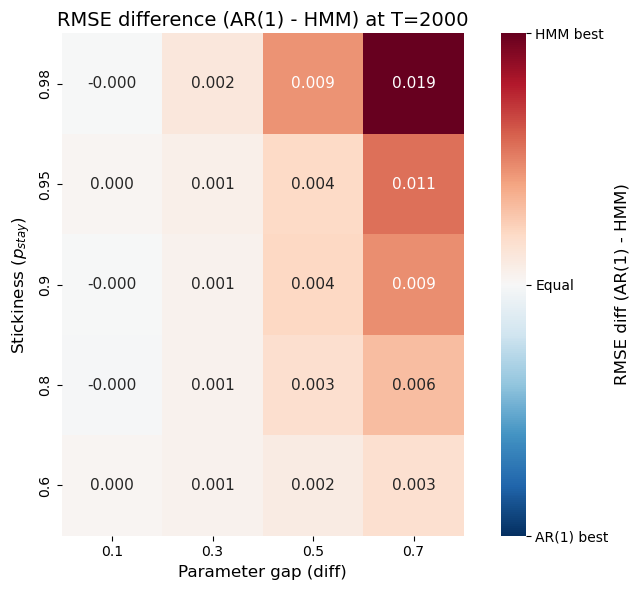

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from methods.plotting import set_style
set_style()

for T in T_vals:
    sub_df = df_agg[df_agg["T"] == T].pivot(
        index="p_stay", columns="diff", values="rmse_diff"
    ).sort_index(ascending=False)

    max_abs = np.nanmax(np.abs(sub_df.values))

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        sub_df,
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
        center=0,
        annot=True,
        fmt=".3f",
        square=True,
        annot_kws={"size": 11}, 
        cbar_kws={
            "label": "RMSE diff (AR(1) - HMM)",
            "ticks": [-max_abs, 0, max_abs],
        }
    )

    cbar = ax.collections[0].colorbar
    cbar.set_ticklabels(["AR(1) best", "Equal", "HMM best"])

    ax.set_title(f"RMSE difference (AR(1) - HMM) at T={T}")
    ax.set_xlabel("Parameter gap (diff)")
    ax.set_ylabel("Stickiness ($p_{stay}$)")

    plt.tight_layout()
    plt.savefig(f"../plots/RMSE_diff_hmm_ar1_simulated_T{T}.pdf", bbox_inches="tight", format="pdf")
    plt.show()


## Conclusion

The heatmaps reveal that HMM outperforms single AR(1) when states are sticky (high p_stay), parameters differ significantly, and sample size is large. This aligns with theory: HMM captures regime shifts better under these conditions.